# Multifidelity testing

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys

from scipy.stats import uniform, multivariate_normal, Normal, norm

sys.path.append(os.path.join(os.getcwd(), "../../"))
sys.path.append(os.path.join(os.getcwd(), "../../smcpy"))
from smcpy.mcmc.vector_mcmc import VectorMCMC
from smcpy.mcmc.vector_mcmc_kernel import VectorMCMCKernel
from smcpy import AdaptiveSampler as Sampler
from smcpy.paths import GeometricPath

from toy_helpers import M_HF, M_LF, generate_noisy_data
from smcpy.mfmc_proposal import MultiFidelityProposal
from smcpy.proposals import MultivarIndependent

In [2]:
# Data generation details
STD_DEV = 0.2
theta_0 = 1/20
theta_1 = 1
THETA_TRUE = np.array([[theta_0, theta_1]])
NUM_PARTICLES = 4_000
np.random.seed(42)
noisy_data = generate_noisy_data(THETA_TRUE, STD_DEV)

## Helper functions

In [3]:
def plot_target_boxplots(true_values, **series):
    """Plot box plots for each parameter and series over the phi sequence.

    Args:
        true_values: array-like of true parameter values in param order
        **series: label=(targets_list, phi_sequence) for each SMC run
    """
    first_targets, _ = next(iter(series.values()))
    param_names = first_targets[0].param_names
    n_params = len(param_names)
    n_series = len(series)

    fig, axes = plt.subplots(
        n_params,
        n_series,
        sharex="col",
        sharey="row",
        figsize=(4 * n_series, 3 * n_params),
    )
    axes = np.atleast_2d(axes)

    for col, (label, (targets, phi_sequence)) in enumerate(series.items()):
        positions = np.arange(len(phi_sequence))
        box_width = 0.6
        for row, (name, true_val) in enumerate(zip(param_names, true_values)):
            ax = axes[row, col]
            ax.boxplot(
                [target.params[:, row] for target in targets],
                positions=positions,
                widths=box_width,
                patch_artist=True,
                manage_ticks=False,
            )
            ax.axhline(
                true_val,
                color="r",
                linestyle="--",
                linewidth=1.5,
                label="true value",
                alpha=0.7,
            )
            ax.grid(True)
            if col == 0:
                ax.set_ylabel(f"${name}$")
        axes[0, col].set_title(label + f" ({len(targets)} steps)")

    for col in range(n_series):
        axes[-1, col].set_xlabel("step")

    axes[0, -1].legend(loc="upper right")
    plt.tight_layout()
    plt.show()

In [4]:
def plot_2d_joint_posterior(true_values, **series):
    """
    Plots a 2D scatter of the joint posterior particles for each SMC run.

    Args:
        true_values: Array-like of true parameter values (needs at least 2 values).
        **series: label=(targets_list, phi_sequence) for each SMC run.
    """
    n_series = len(series)
    
    # Extract true values from the array (fixes the undefined variables bug)
    theta_0, theta_1 = true_values[0], true_values[1]

    # Create subplots
    fig, axes = plt.subplots(
        1,
        n_series,
        sharex="col",
        sharey="row",
        figsize=(6 * n_series, 6), # slightly adjusted size for better proportions
    )
    
    # Ensure axes is a 1D array so we can index it cleanly, even if n_series == 1
    axes = np.atleast_1d(axes)

    # Unpack the series tuple directly in the loop
    for col, (label, targets) in enumerate(series.items()):
        ax = axes[col]
        
        # Plot posterior particles
        ax.scatter(
            targets[-1].params[:, 0],
            targets[-1].params[:, 1],
            alpha=0.3,           
            s=20,                
            color='mediumblue',  
            edgecolors='none',   
            label='Posterior Particles'
        )

        # Plot True values lines using the specific Axis object (ax)
        ax.axvline(theta_0, color='r', linestyle='--', alpha=0.8, linewidth=2)
        ax.axhline(theta_1, color='r', linestyle='--', alpha=0.8, linewidth=2)

        # Add a marker right at the exact true value intersection
        ax.plot(theta_0, theta_1, marker='*', color='red', markersize=15, 
                linestyle='None', label='True Theta')

        # Labels and Titles
        ax.set_xlabel(r'$\theta_0$', fontsize=14)
        ax.set_title(label, fontsize=16, pad=15)
        
        # Only add the y-label to the first plot since the y-axis is shared
        if col == 0:
            ax.set_ylabel(r'$\theta_1$', fontsize=14)

        # Add a subtle background grid for readability
        ax.grid(True, alpha=0.5)

        # Make tick marks slightly larger
        ax.tick_params(axis='both', which='major', labelsize=12)

    # Add the legend to the last axis
    axes[-1].legend(loc="upper right")
    
    plt.tight_layout()
    plt.show()

In [5]:
def plot_param_hists(true_values, **series):
    """
    Plots a histogram of the marginal posterior for each parameter (columns) 
    across each SMC run (rows).

    Args:
        true_values: Array-like of true parameter values.
        **series: label=(targets_list, phi_sequence) for each SMC run.
    """
    n_runs = len(series)
    n_params = len(true_values)
    
    # Create subplots: n_runs (rows) x n_params (columns)
    # squeeze=False ensures `axes` is strictly a 2D array: shape (n_runs, n_params)
    fig, axes = plt.subplots(
        n_runs,
        n_params,
        sharex="col",  # X-axis shared across the same parameter (columns)
        figsize=(4 * n_params, 3 * n_runs), 
        squeeze=False 
    )

    for row, (label, series_data) in enumerate(series.items()):
        # Handle unpacking just in case `series_data` is a tuple (targets, phi_sequence)
        if isinstance(series_data, tuple) and len(series_data) == 2:
            targets = series_data[0]
        else:
            targets = series_data
            
        # Extract the final particles for this specific SMC run
        final_particles = targets[-1].params
        
        for col in range(n_params):
            ax = axes[row, col]
            
            # Plot the histogram for this specific parameter
            ax.hist(
                final_particles[:, col],
                bins=30,
                density=True,      # Normalizes the histogram to represent a probability density
                alpha=0.7,           
                label='Posterior Density' if row == 0 and col == 0 else None,
                color = 'mediumblue'
            )

            # Plot True value line
            true_val = true_values[col]
            ax.axvline(true_val, color='r', linestyle='--', alpha=0.8, linewidth=2, 
                       label='True Value' if row == 0 and col == 0 else None)

            # --- Formatting and Labels ---
            
            # Put the parameter symbol as the title on the top row
            if row == 0:
                ax.set_title(r'$\theta_{%d}$' % col, fontsize=16, pad=10)
            
            # Put the parameter symbol on the x-axis of the bottom row
            if row == n_runs - 1:
                ax.set_xlabel(r'$\theta_{%d}$' % col, fontsize=14)
            
            # Put the SMC run label on the y-axis of the first column
            if col == 0:
                ax.set_ylabel(f'{label}\nDensity', fontsize=14)

            # Clean up the background grid and ticks
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='both', which='major', labelsize=11)

    axes[0,0].legend(loc="upper right")
    
    plt.tight_layout()
    # Adjust top margin so the figure legend doesn't overlap titles
    plt.subplots_adjust(top=0.9) 
    plt.show()

## Run algorithm

Currently we will work with the case where we know the standard deviation of the additive noise term.

In [6]:
priors = [uniform(0.001, 2), uniform(-2, 8)]
vector_mcmc = VectorMCMC(M_LF, noisy_data, priors, STD_DEV)

# initialize from prior
mcmc_kernel = VectorMCMCKernel(vector_mcmc, param_order=("theta_0", "theta_1"))
smc = Sampler(mcmc_kernel=mcmc_kernel, show_progress_bar=True)
lofi_step_list, lofi_mll_list = smc.sample(
    num_particles=NUM_PARTICLES,
    num_mcmc_samples=7,
    target_ess=0.75
)
lofi_phi_list = smc.phi_sequence

[ mutation ratio: 0.997: : 100.00%|██████████| phi: 1.00000/1.0 [05:43<00:00      


In [7]:
lofi_particles = lofi_step_list[-1].params

In [8]:
lofi_proposal_dist = MultiFidelityProposal(
    lofi_particles, 
    M_LF, 
    noisy_data,
    priors,
    STD_DEV
)

In [9]:
mcmc_kernel = VectorMCMCKernel(
    vector_mcmc, param_order=("a", "b"), path=GeometricPath(proposal=lofi_proposal_dist)
)

In [10]:
hifi_smc = Sampler(mcmc_kernel=mcmc_kernel, show_progress_bar=True)
hifi_step_list, hifi_mll_list = hifi_smc.sample(
    num_particles=NUM_PARTICLES,
    num_mcmc_samples=5,
    target_ess=0.75,
    # phi_sequence=phi_sequence,
    # ess_threshold=1.0,
)
hifi_phi_list = hifi_smc.phi_sequence

[ mutation ratio: 0.98425: : 100.00%|██████████| phi: 1.00000/1.0 [00:31<00:00


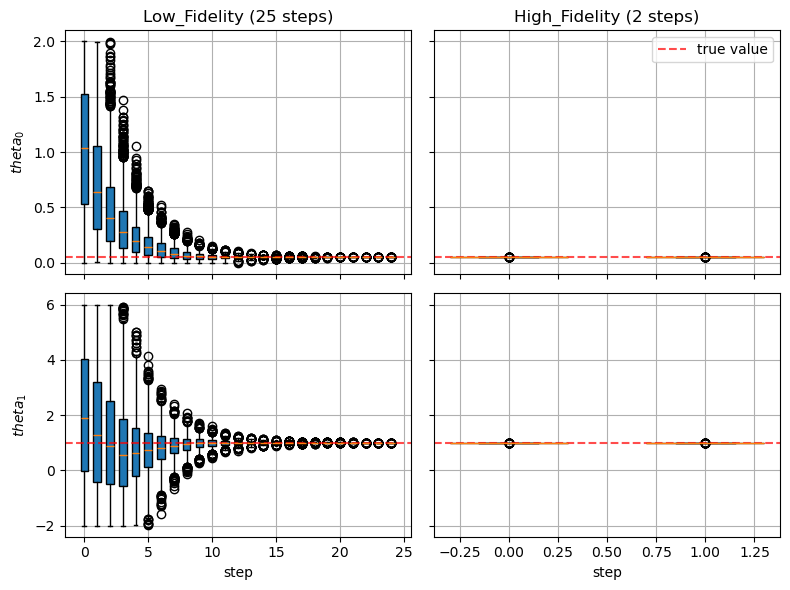

In [11]:
plot_target_boxplots(
    THETA_TRUE.flatten(),
    Low_Fidelity=(lofi_step_list, lofi_phi_list),
    High_Fidelity=(hifi_step_list, hifi_phi_list),
)

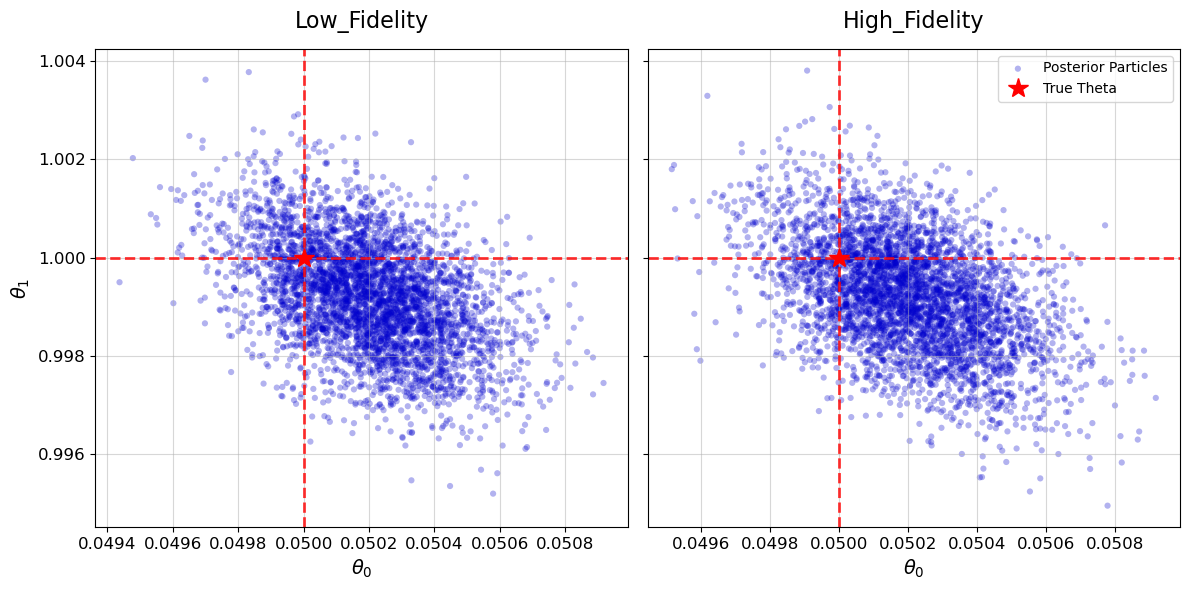

In [12]:
plot_2d_joint_posterior(
    THETA_TRUE.flatten(),
    Low_Fidelity=lofi_step_list,
    High_Fidelity=hifi_step_list,
)

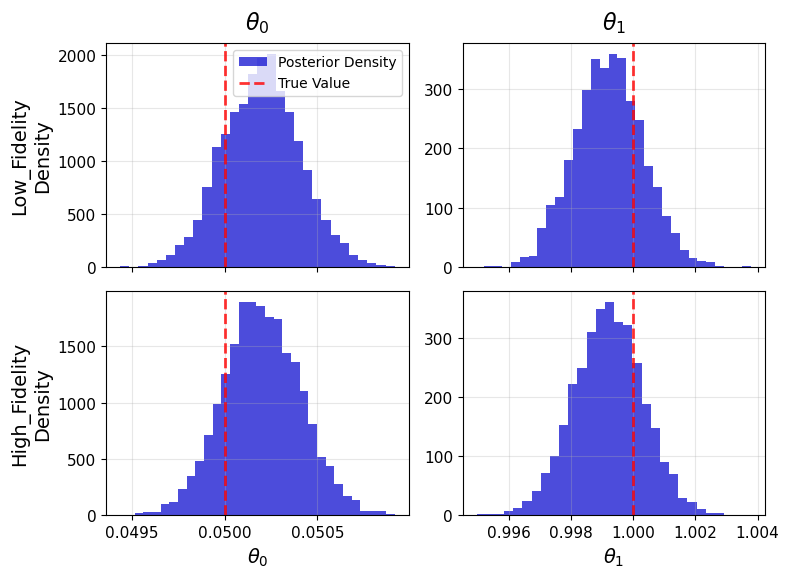

In [13]:
plot_param_hists(
    THETA_TRUE.flatten(),
    Low_Fidelity=lofi_step_list,
    High_Fidelity=hifi_step_list
    )

### Prototyping

In [ ]:
dims_here = [d.rvs(1).size for d in priors]

In [ ]:
np.split(lofi_samples, np.cumsum(dims_here)[:-1], axis=1)

In [ ]:
uniform(1,2)

In [ ]:
mf_proposal = MultiFidelityProposal(
    lofi_samples, 
    M_LF, 
    noisy_data,
    STD_DEV
)
og_proposal = MultivarIndependent(uniform(1,2), uniform(1,3))

In [ ]:
len(lofi_samples)

In [ ]:
# testing on original proposal module

# Draw sample
og_test_sample = og_proposal.rvs(num_samples = 1000)

# Eval log pdf
og_log_pdf_res = og_proposal.logpdf(og_test_sample)
print(og_log_pdf_res.shape)


In [ ]:
# testing on mf proposal

# draw sample
mf_test_sample = mf_proposal.rvs(num_samples = 1000, random_state= 42)
# print(len(mf_test_sample))

# Eval log pdf
mf_log_pdf_res = mf_proposal.logpdf(mf_test_sample)
print(mf_log_pdf_res.shape)
